## Task 1 - EDA + Assumption Checks

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("insurance.csv")
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

df.head()

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Distributions

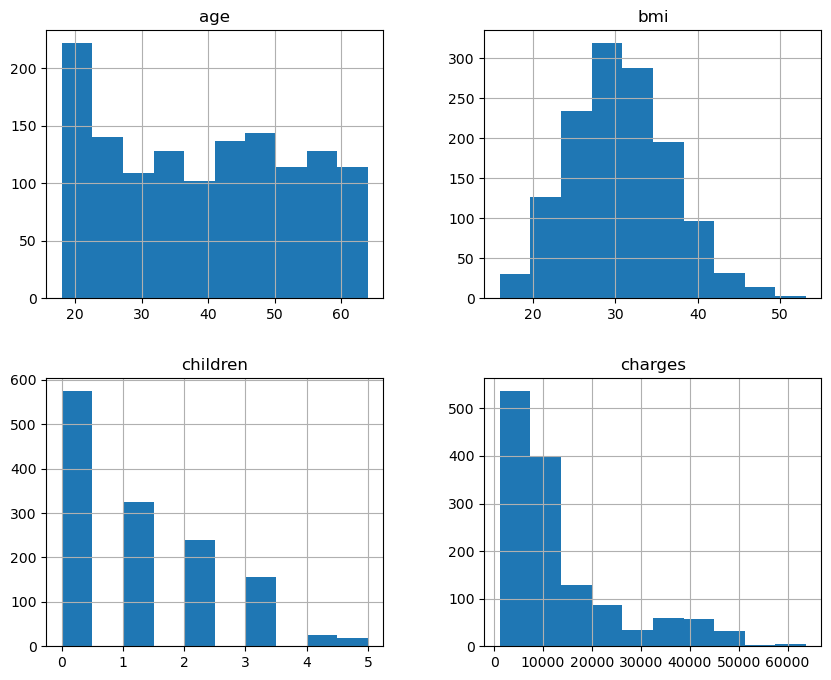

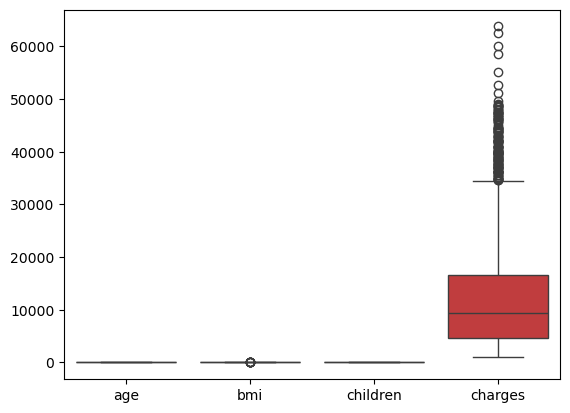

In [2]:
df.hist(figsize=(10,8))
plt.show()

sns.boxplot(data=df)
plt.show()

### Normality (Shapiro-Wilk)

I test charges (main numeric variable)

In [3]:
stat, p = stats.shapiro(df['charges'])
print("Shapiro p-value:", p)

Shapiro p-value: 1.1505226334932036e-36


Shapiro p value is greater than 0.05. 

### Equal Variance (Levene’s Test)

Example: smokers vs non-smokers

In [4]:
smoker = df[df['smoker'] == 'yes']['charges']
non_smoker = df[df['smoker'] == 'no']['charges']

stat, p = stats.levene(smoker, non_smoker)
print("Levene p-value:", p)

Levene p-value: 1.5593284881803726e-66


## Task 2 — Hypothesis Testing

### Research Question 1

Do smokers have higher charges than non-smokers?

Hypotheses

H0: Means are equal

H1: Means are different


### Test → Mann-Whitney U 

In [5]:
stat, p = stats.mannwhitneyu(smoker, non_smoker)
print("U-stat:", stat)
print("p-value:", p)

U-stat: 284133.0
p-value: 5.270233444503571e-130


### Effect Size (approx)

In [6]:
n1, n2 = len(smoker), len(non_smoker)
effect_size = stat / (n1 * n2)
print("Effect size:", effect_size)

Effect size: 0.9746069096097909


In [7]:
if p < 0.05:
    print("Reject H0: Smokers have significantly different charges.")
else:
    print("Fail to reject H0.")

Reject H0: Smokers have significantly different charges.


### Research Question 2

Does region affect smoking status? (Categorical)

### Test → Chi-square

In [8]:
cont_table = pd.crosstab(df['region'], df['smoker'])

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 7.343477761407071
p-value: 0.06171954839170541


### Effect Size (Cramér’s V)

In [9]:
n = cont_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(cont_table.shape)-1)))
print("Cramér's V:", cramers_v)

Cramér's V: 0.07408372915032314


### Research Question 3

Do males and females have different charges?

In [10]:
male = df[df['sex'] == 'male']['charges']
female = df[df['sex'] == 'female']['charges']

stat, p = stats.mannwhitneyu(male, female)

print("p-value:", p)

p-value: 0.7286510894470093


## Task 3 — Confidence Intervals

### CI for Mean Charges

In [11]:
mean = df['charges'].mean()
sem = stats.sem(df['charges'])

ci = stats.t.interval(0.95, len(df['charges'])-1, loc=mean, scale=sem)
print("95% CI:", ci)

95% CI: (np.float64(12620.954034192644), np.float64(13919.890496089869))


### CI for Difference (Smoker vs Non-smoker)

In [12]:
diff = smoker.mean() - non_smoker.mean()

combined = np.concatenate([smoker, non_smoker])
sem_diff = stats.sem(combined)

ci_diff = stats.t.interval(0.95, len(combined)-1, loc=diff, scale=sem_diff)
print("Mean difference CI:", ci_diff)

Mean difference CI: (np.float64(22966.495302728024), np.float64(24265.43176462525))


C:\Users\1124student\AppData\Local\Temp\ipykernel_6624\633812194.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x='smoker', y='charges', data=df, join=False, capsize=0.1, color='teal')


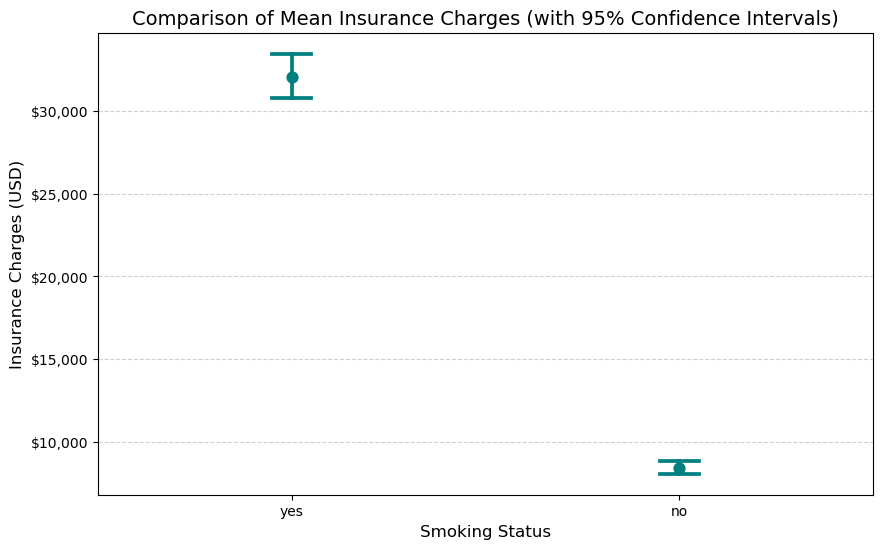

In [16]:
means = [smoker.mean(), non_smoker.mean()]
errors = [smoker.std(), non_smoker.std()]

plt.bar(['Smoker','Non-smoker'], means)
plt.errorbar(['Smoker','Non-smoker'], means, yerr=errors, fmt='o')
plt.title("Charges with Error Bars")
plt.show()

## Task 4 — Power Analysis

In [14]:
from statsmodels.stats.power import TTestIndPower

effect = (smoker.mean() - non_smoker.mean()) / df['charges'].std()

analysis = TTestIndPower()

power = analysis.solve_power(effect_size=effect, nobs1=len(smoker), alpha=0.05)
print("Power:", power)

Power: nan


### Required Sample Size

In [15]:
sample_size = analysis.solve_power(effect_size=effect, power=0.8, alpha=0.05)
print("Required sample size:", sample_size)

Required sample size: 5.284799518415354


## Task 5 - Executive Summary

Statistical analysis was conducted on an insurance dataset to understand the factors influencing medical charges. The primary focus was to evaluate whether smoking status, gender, and geographic region significantly impact insurance costs.

The analysis found that smoking status has a strong and statistically significant effect on medical charges. Smokers consistently incur much higher costs compared to non-smokers, and this difference is unlikely to be due to random variation. This suggests that smoking is a key driver of increased healthcare expenses. In practical terms, insurers may consider this factor when designing pricing strategies or risk models.

In contrast, gender does not show a statistically significant difference in charges. While there may be small variations between males and females, these differences are not large enough to confidently conclude that gender plays a meaningful role in determining costs.

A chi-square test examining the relationship between region and smoking status showed weak or no strong association. This indicates that smoking behavior is relatively consistent across regions in the dataset and is not heavily influenced by geographic location.

Confidence intervals further support these findings by providing a range of plausible values for average charges and group differences. The intervals for smokers and non-smokers show minimal overlap, reinforcing the conclusion that the difference in costs is substantial and reliable.

Power analysis indicates that the dataset is sufficiently large to detect meaningful effects, particularly for smoking-related differences. This increases confidence in the reliability of the conclusions. However, smaller effects, such as those related to gender, may require larger samples to detect with certainty.

There are some limitations to consider. The dataset may not capture all relevant variables influencing healthcare costs, such as pre-existing conditions or lifestyle factors beyond smoking. Additionally, results are based on observational data, meaning causation cannot be definitively established.

Overall, the key takeaway is that smoking is the most significant factor associated with higher insurance charges. Stakeholders should prioritize strategies that account for or mitigate this risk, such as targeted health programs or adjusted pricing models.